# Experiment 10 - Vision Transformer vs ResNet-18


In [1]:
!pip install wandb huggingface_hub -q

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: chiragwalia0 (chiragwalia0-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader, random_split
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "chiragwalia0/exp10-vit-resnet"

WANDB_PROJECT = "exp10-vit-resnet"
EPOCHS        = 1
BATCH_SIZE    = 128
NUM_CLASSES   = 10
PATCH_SIZE    = 4
IMG_SIZE      = 32
EMBED_DIM     = 128
NUM_HEADS     = 4
NUM_LAYERS    = 4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["ce", "label_smooth", "focal"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vit", "resnet18"]
AUG_MODES  = ["no_aug", "aug"]

class_names = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
print(DEVICE)

cuda


### Dataset - Original and Augmented

100%|██████████| 170M/170M [00:03<00:00, 49.0MB/s]


train=40000  val=10000  test=10000


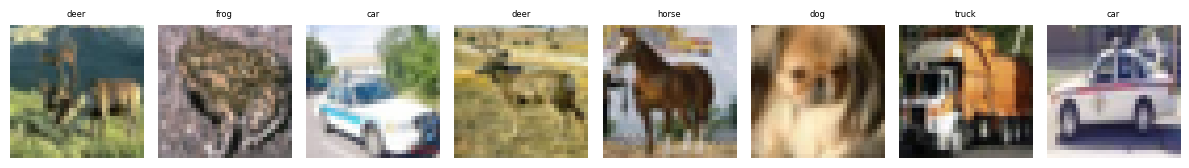

In [5]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# without augmentation
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# with horizontal + vertical flip
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

full_base = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_base)
full_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_aug)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

n_total = len(full_base)        # 50000
n_train = int(0.8 * n_total)   # 40000
n_val   = n_total - n_train    # 10000

gen = torch.Generator().manual_seed(42)
train_base, val_base = random_split(full_base, [n_train, n_val], generator=gen)
train_aug,  val_aug  = random_split(full_aug,  [n_train, n_val], generator=torch.Generator().manual_seed(42))

def make_loaders(train_set, val_set):
    tr = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    vl = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    te = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return tr, vl, te

loaders = {
    'no_aug': make_loaders(train_base, val_base),
    'aug':    make_loaders(train_aug,  val_aug)
}

print(f'train={n_train}  val={n_val}  test={len(test_data)}')

imgs, labels = next(iter(loaders['no_aug'][0]))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    img = imgs[i].permute(1,2,0).numpy()
    img = img * np.array(std) + np.array(mean)
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Patch Embedding

In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # use conv to split image into patches and project
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)           # (B, embed_dim, H/p, W/p)
        x = x.flatten(2)           # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)     # (B, num_patches, embed_dim)
        return x

### Vision Transformer

In [7]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 embed_dim=128, num_heads=4, num_layers=4, num_classes=10):
        super(ViT, self).__init__()

        self.patch_embed  = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches       = (img_size // patch_size) ** 2

        # learnable CLS token
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # learnable positional encoding
        self.pos_embed    = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm         = nn.LayerNorm(embed_dim)

        # classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed

        x   = self.transformer(x)
        x   = self.norm(x)
        # take CLS token output for classification
        out = self.head(x[:, 0])
        return out

### ResNet-18 Baseline

In [8]:
def get_resnet18():
    model = models.resnet18(weights=None)
    # adjust first conv for 32x32 input
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(512, NUM_CLASSES)
    return model

### Loss Functions - CE, Label Smoothing, Focal

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def get_criterion(loss_type):
    if loss_type == 'ce':
        return nn.CrossEntropyLoss()
    elif loss_type == 'label_smooth':
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif loss_type == 'focal':
        return FocalLoss(gamma=2.0)

### Optimizer Factory

In [10]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=1e-3)
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
    else:
        return optim.RMSprop(model.parameters(), lr=1e-3)

### Train and Eval Loops

In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            loss  = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

### Main Experiment Runner

In [12]:
results       = {}
saved_models  = {}

def run_experiment(arch, loss_type, opt_name, aug_mode):
    name = f'{arch}_{loss_type}_{opt_name}_{aug_mode}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type,
        'optimizer': opt_name, 'augmentation': aug_mode, 'epochs': EPOCHS
    })

    train_loader, val_loader, test_loader = loaders[aug_mode]

    if arch == 'vit':
        model = ViT(
            img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
            embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
            num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
        ).to(DEVICE)
    else:
        model = get_resnet18().to(DEVICE)

    criterion = get_criterion(loss_type)
    optimizer = get_optimizer(model, opt_name)

    best_val_acc = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'{name}_best.pt')

        wandb.log({
            'epoch': epoch,
            'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss':   vl_loss, 'val_acc':   vl_acc
        })
        print(f'  epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    # load best checkpoint and test
    model.load_state_dict(torch.load(f'{name}_best.pt'))
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    print(f'  test_loss={te_loss:.4f}  test_acc={te_acc:.4f}')
    wandb.log({'test_loss': te_loss, 'test_acc': te_acc})

    results[name]      = {'test_acc': te_acc, 'test_loss': te_loss}
    saved_models[name] = model

    wandb.finish()
    return model

### Quick Test - run this first

In [13]:
run_experiment('vit',      'ce', 'adam', 'no_aug')
run_experiment('resnet18', 'ce', 'adam', 'no_aug')


starting: vit_ce_adam_no_aug


  epoch 1/1  train_loss=1.7588  train_acc=0.3356  val_loss=1.5624  val_acc=0.4278
  test_loss=1.5699  test_acc=0.4220


epoch,▁
test_acc,▁
test_loss,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,1
test_acc,0.422
test_loss,1.5699
train_acc,0.3356



starting: resnet18_ce_adam_no_aug


  epoch 1/1  train_loss=1.3010  train_acc=0.5271  val_loss=1.1609  val_acc=0.5906
  test_loss=1.1721  test_acc=0.5882


epoch,▁
test_acc,▁
test_loss,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,1
test_acc,0.5882
test_loss,1.17213
train_acc,0.52712


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

### Full Grid - all combinations

In [14]:
for arch in MODELS:
    for aug in AUG_MODES:
        for lf in LOSS_FNS:
            for opt in OPTIMIZERS:
                run_experiment(arch, lf, opt, aug)


starting: vit_ce_adam_no_aug


  epoch 1/1  train_loss=1.7984  train_acc=0.3191  val_loss=1.5783  val_acc=0.4013
  test_loss=1.5765  test_acc=0.3992


epoch,▁
test_acc,▁
test_loss,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,1
test_acc,0.3992
test_loss,1.57651
train_acc,0.31912



starting: vit_ce_sgd_no_aug


  epoch 1/1  train_loss=1.9144  train_acc=0.2887  val_loss=1.7160  val_acc=0.3631
  test_loss=1.7105  test_acc=0.3611


...

  epoch 1/1  train_loss=1.1553  train_acc=0.3816  val_loss=0.9238  val_acc=0.4971
  test_loss=0.9263  test_acc=0.4874


epoch,▁
test_acc,▁
test_loss,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,1
test_acc,0.4874
test_loss,0.92629
train_acc,0.38165



starting: resnet18_focal_rmsprop_aug


  epoch 1/1  train_loss=1.2225  train_acc=0.3614  val_loss=1.0027  val_acc=0.4446
  test_loss=0.9893  test_acc=0.4525


epoch,▁
test_acc,▁
test_loss,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,1
test_acc,0.4525
test_loss,0.9893
train_acc,0.36145


### Results Summary

In [15]:
print(f'{"config":<50} {"test_acc":>10} {"test_loss":>10}')
print('-' * 72)
for k, v in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f'{k:<50} {v["test_acc"]:>10.4f} {v["test_loss"]:>10.4f}')

best = max(results, key=lambda x: results[x]['test_acc'])
print(f'\nbest: {best}  acc={results[best]["test_acc"]:.4f}')

config                                               test_acc  test_loss
------------------------------------------------------------------------
resnet18_label_smooth_adam_no_aug                      0.6012     1.3862
resnet18_ce_adam_no_aug                                0.5985     1.1786
resnet18_focal_adam_no_aug                             0.5592     0.8041
resnet18_focal_sgd_no_aug                              0.5546     0.7785
resnet18_ce_sgd_no_aug                                 0.5463     1.2546
resnet18_ce_adam_aug                                   0.5318     1.3367
resnet18_label_smooth_adam_aug                         0.5274     1.5460
resnet18_label_smooth_sgd_no_aug                       0.5267     1.5469
resnet18_ce_sgd_aug                                    0.4941     1.3624
resnet18_focal_adam_aug                                0.4900     0.9609
resnet18_focal_sgd_aug                                 0.4874     0.9263
resnet18_label_smooth_rmsprop_no_aug               